Iteration 1: Best Length = 27.66
Iteration 2: Best Length = 26.41
Iteration 3: Best Length = 26.41
Iteration 4: Best Length = 26.41
Iteration 5: Best Length = 26.41
Iteration 6: Best Length = 26.41
Iteration 7: Best Length = 26.41
Iteration 8: Best Length = 26.41
Iteration 9: Best Length = 26.41
Iteration 10: Best Length = 26.41
Iteration 11: Best Length = 26.41
Iteration 12: Best Length = 26.41
Iteration 13: Best Length = 26.41
Iteration 14: Best Length = 26.41
Iteration 15: Best Length = 26.41
Iteration 16: Best Length = 26.41
Iteration 17: Best Length = 26.41
Iteration 18: Best Length = 26.41
Iteration 19: Best Length = 26.41
Iteration 20: Best Length = 26.41
Iteration 21: Best Length = 26.41
Iteration 22: Best Length = 26.41
Iteration 23: Best Length = 26.41
Iteration 24: Best Length = 26.41
Iteration 25: Best Length = 26.41
Iteration 26: Best Length = 26.41
Iteration 27: Best Length = 26.41
Iteration 28: Best Length = 26.41
Iteration 29: Best Length = 26.41
Iteration 30: Best Leng

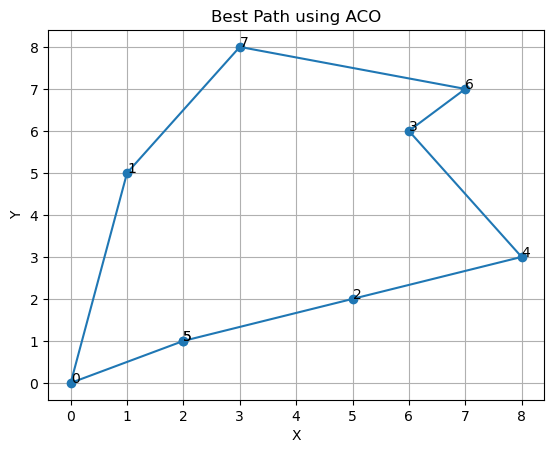

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ----- Step 1: Define Cities -----
cities = np.array([
    [0, 0], [1, 5], [5, 2], [6, 6],
    [8, 3], [2, 1], [7, 7], [3, 8]
])

num_cities = len(cities)

# Distance matrix
distance_matrix = np.linalg.norm(
    cities[:, np.newaxis] - cities[np.newaxis, :], axis=2
)

# ----- Step 2: Parameters -----
num_ants = 10
alpha = 1
beta = 5
evaporation_rate = 0.5
pheromone_deposit = 100
max_iter = 100

pheromone_matrix = np.ones((num_cities, num_cities))
best_length = float('inf')
best_path = []

# ----- Step 3: ACO Algorithm -----
for iteration in range(max_iter):
    all_paths = []
    all_lengths = []

    for ant in range(num_ants):
        visited = [random.randint(0, num_cities - 1)]
        unvisited = list(set(range(num_cities)) - set(visited))

        while unvisited:
            current = visited[-1]
            probabilities = []

            for city in unvisited:
                pheromone = pheromone_matrix[current][city] ** alpha
                visibility = (1 / distance_matrix[current][city]) ** beta
                probabilities.append(pheromone * visibility)

            probabilities = np.array(probabilities)
            probabilities = probabilities / probabilities.sum()

            next_city = random.choices(unvisited, weights=probabilities)[0]
            visited.append(next_city)
            unvisited.remove(next_city)

        visited.append(visited[0])  # return to start

        # Calculate length
        length = 0
        for i in range(num_cities):
            length += distance_matrix[visited[i]][visited[i + 1]]

        all_paths.append(visited)
        all_lengths.append(length)

        # Update best
        if length < best_length:
            best_length = length
            best_path = visited

    # ----- Step 4: Update Pheromones -----
    pheromone_matrix *= (1 - evaporation_rate)

    for path, length in zip(all_paths, all_lengths):
        for i in range(num_cities):
            a, b = path[i], path[i + 1]
            pheromone_matrix[a][b] += pheromone_deposit / length
            pheromone_matrix[b][a] += pheromone_deposit / length

    print(f"Iteration {iteration + 1}: Best Length = {best_length:.2f}")

# ----- Step 5: Output -----
print("\nBest Path:", best_path)
print("Shortest Distance:", round(best_length, 2))

# ----- Visualization -----
x = [cities[i][0] for i in best_path]
y = [cities[i][1] for i in best_path]

plt.plot(x, y, marker='o')
for i in range(len(best_path)):
    city = best_path[i]
    plt.text(cities[city][0], cities[city][1], str(city))

plt.title("Best Path using ACO")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()